# World Happiness Report 2024 — Regression Analysis

This notebook analyses the World Happiness Report dataset to understand which factors best explain cross-country differences in happiness scores.

We use the `fit_and_plot` helper to fit each OLS model and immediately produce a 3-panel diagnostic plot.

## 1. Import Libraries

In [1]:
import pandas as pd                          # data manipulation and DataFrames
import matplotlib.pyplot as plt               # base plotting library
import seaborn as sns                          # statistical visualisations
import numpy as np                             # numerical operations
import statsmodels.api as sm                   # statistical modelling
import statsmodels.formula.api as smf          # R-style formula API for OLS
from statsmodels.iolib.summary2 import summary_col  # model comparison table
from scipy import stats                        # probplot for the Q-Q panel
import warnings                                # suppress noisy warnings

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['font.size']   = 12
plt.rcParams['font.family'] = 'sans-serif'

## 2. Helper Function: `fit_and_plot`

Fits an OLS model and produces a 3-panel diagnostic plot:
- **Top**: actual vs predicted (scatter for continuous x, stripplot + mean lines for categorical x)
- **Bottom-left**: residuals vs fitted
- **Bottom-right**: Q-Q plot of residuals

In [14]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()
    print(model.summary())

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    residuals = model.resid

    # Use only the rows the model was actually fitted on (drops NaN rows)
    model_data = data.loc[model.fittedvalues.index]

    is_cat = model_data[x_var].dtype == object or str(model_data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # --- Panel 1: Actual vs Predicted ---
    if is_cat:
        sns.stripplot(x=model_data[x_var], y=model_data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = model_data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(model_data[x_var].values, model_data[y_var].values,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(model_data[x_var].values, model.fittedvalues.values,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted -- x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # --- Panel 2: Residuals vs Fitted ---
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # --- Panel 3: Q-Q Plot ---
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    plt.suptitle(f'{model_name}  |  R2 = {model.rsquared:.3f}  |  Adj R2 = {model.rsquared_adj:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model

## 3. Load & Inspect Data

In [ ]:
world_happiness = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/world_happiness.csv")

print(f"Shape: {world_happiness.shape}")
world_happiness.info()

Shape: (147, 10)
<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     147 non-null    int64  
 1   country                  147 non-null    str    
 2   happiness                147 non-null    float64
 3   gdp_percapita            147 non-null    float64
 4   social_support           147 non-null    float64
 5   healthy_life_expectancy  146 non-null    float64
 6   freedom_life_choices     146 non-null    float64
 7   generosity               147 non-null    float64
 8   corruption               146 non-null    float64
 9   dystopia+residual        144 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 11.6 KB


In [6]:
world_happiness.head()  # preview first 5 rows

,rank,country,happiness,gdp_percapita,social_support,healthy_life_expectancy,freedom_life_choices,generosity,corruption,dystopia+residual
0,1,Finland,7.736,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2,Denmark,7.521,1.825,1.748,0.820,0.955,0.150,0.488,1.535
2,3,Iceland,7.515,1.799,1.840,0.873,0.971,0.201,0.173,1.659
3,4,Sweden,7.345,1.783,1.698,0.889,0.952,0.170,0.467,1.385
4,5,Netherlands,7.306,1.822,1.667,0.844,0.860,0.186,0.344,1.583


## 4. Correlation Heatmap

We drop `rank` (just row order) and `country` (string) before computing correlations.
The heatmap highlights which variables are most strongly associated with happiness.

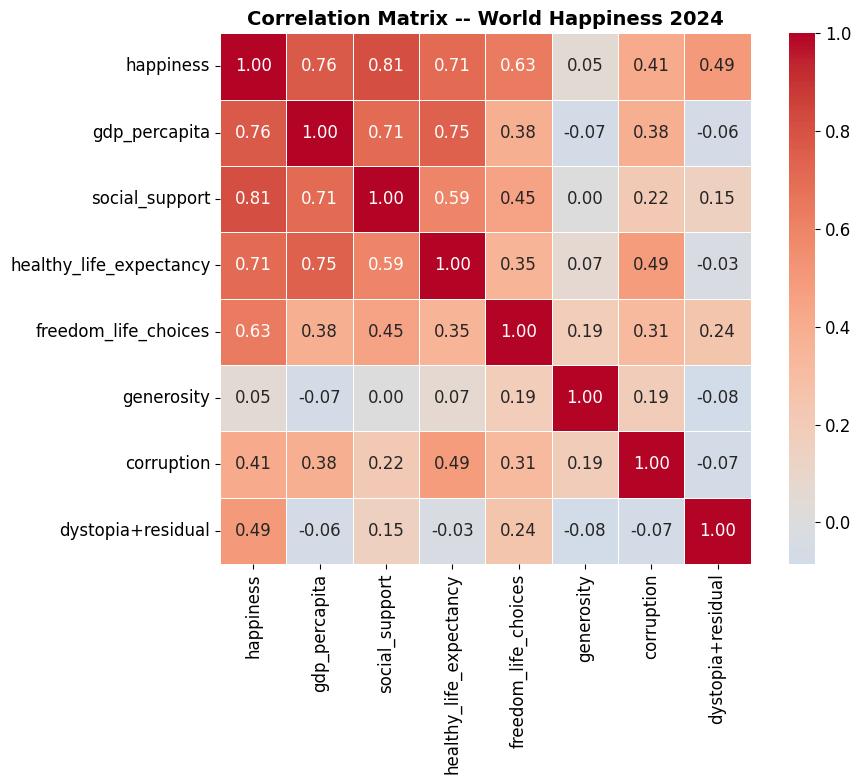

In [7]:
# drop non-numeric columns before calling .corr()
corr_matrix = world_happiness.drop(['rank', 'country'], axis=1).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',          # show r values, 2 decimal places
    cmap='coolwarm', center=0,       # diverging palette centred at zero
    square=True, linewidths=0.5,     # equal-size cells, thin grid lines
    ax=ax
)
ax.set_title('Correlation Matrix -- World Happiness 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [8]:
# Five-number summary of the outcome variable
world_happiness['happiness'].describe().round(2).to_frame().T

,count,mean,std,min,25%,50%,75%,max
happiness,147.0,5.58,1.16,1.36,4.7,5.87,6.48,7.74


## 6. Model Building

Each call to `fit_and_plot` fits the model, prints the full summary, and produces the 3-panel diagnostic plot.

| Model | Formula |
|---|---|
| M1 | Intercept only (baseline) |
| M2 | ~ freedom_life_choices |
| M3 | ~ gdp_percapita + freedom_life_choices |
| M4 | ~ gdp_percapita + social_support + freedom_life_choices |
| M5 | ~ gdp_percapita + healthy_life_expectancy + social_support + freedom_life_choices |

### Model 1 — Intercept Only

Predicts the global mean for every country. R-squared = 0 by definition -- the performance floor.

In [9]:
# Intercept-only: predicts mean(happiness) for every country
# R-squared is 0 by definition -- any real predictor should beat this
model1 = smf.ols('happiness ~ 1', data=world_happiness).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        20:25:08   Log-Likelihood:                -229.68
No. Observations:                 147   AIC:                             461.4
Df Residuals:                     146   BIC:                             464.4
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5782      0.096     58.390      0.0

### Model 2 — Freedom to Make Life Choices

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     96.99
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           8.20e-18
Time:                        20:29:02   Log-Likelihood:                -191.02
No. Observations:                 146   AIC:                             386.0
Df Residuals:                     144   BIC:                             392.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4705 

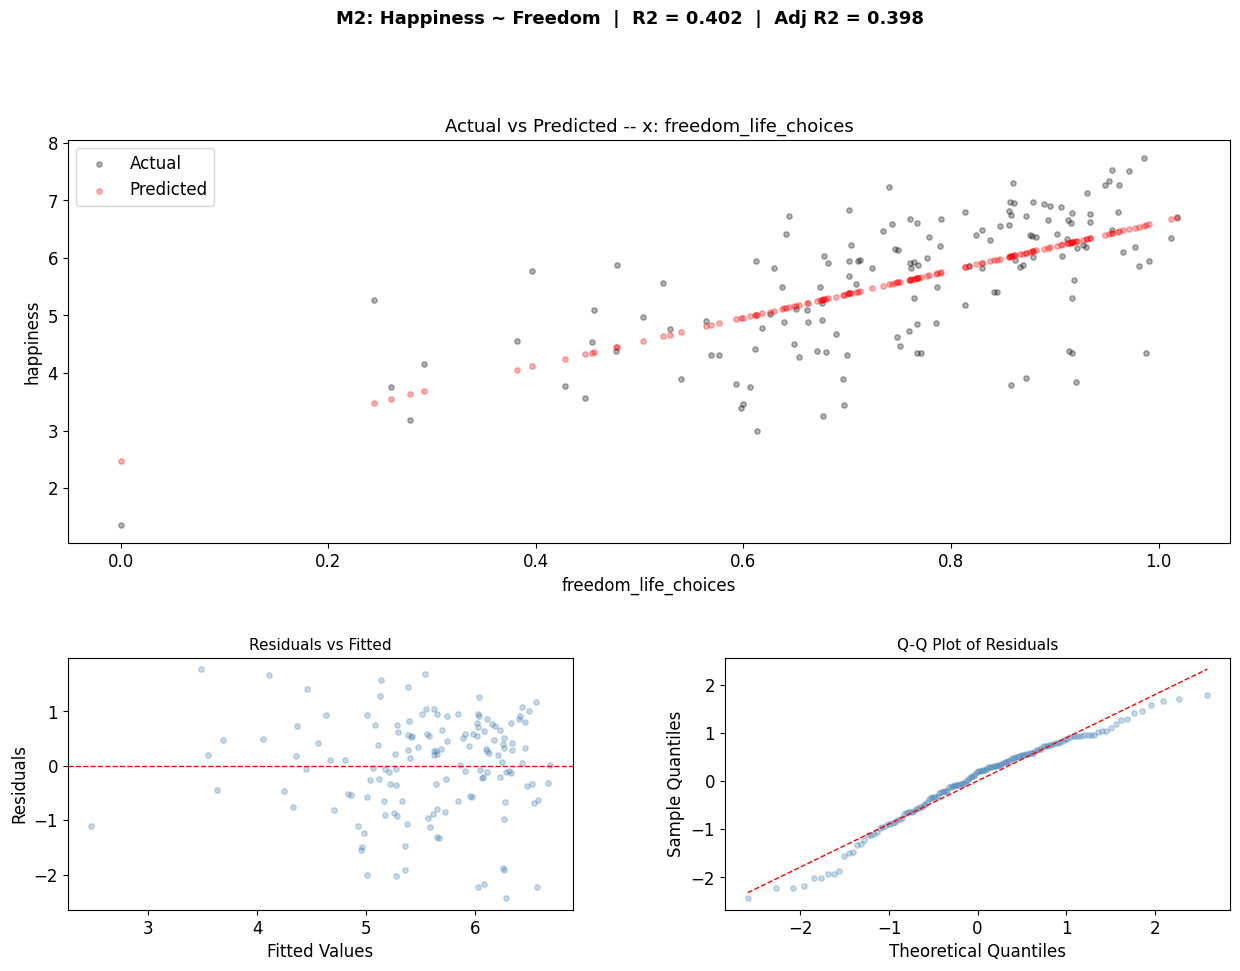

In [15]:
# Single predictor: does perceived autonomy explain national happiness?
model2 = fit_and_plot(
    formula='happiness ~ freedom_life_choices',
    data=world_happiness,
    model_name='M2: Happiness ~ Freedom',
    x_var='freedom_life_choices'
)

### Model 3 — GDP + Freedom

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     186.4
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.47e-40
Time:                        20:29:16   Log-Likelihood:                -134.97
No. Observations:                 146   AIC:                             275.9
Df Residuals:                     143   BIC:                             284.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.2270 

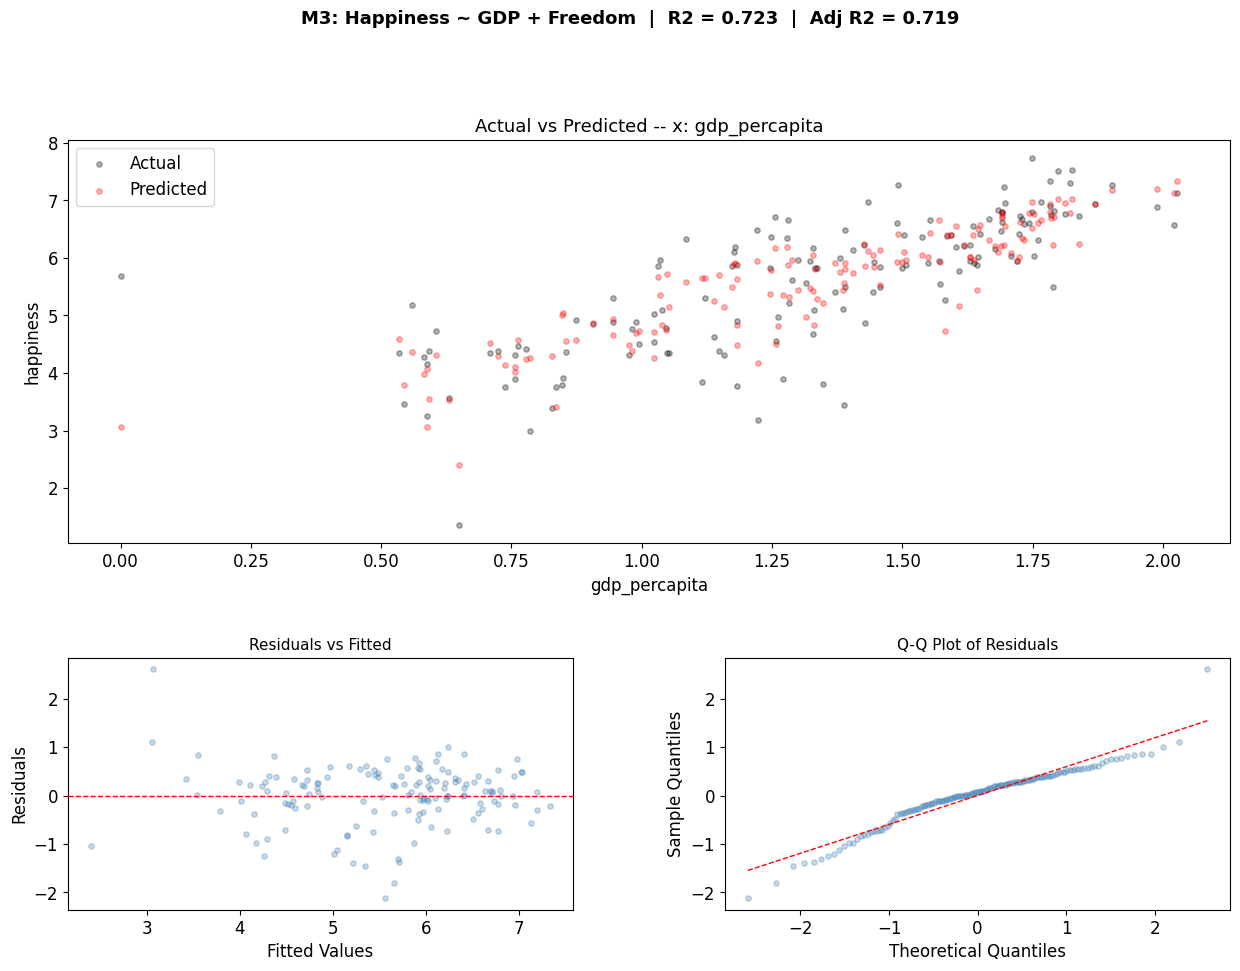

In [16]:
# Add GDP per capita: richer countries tend to be happier even after controlling for freedom
model3 = fit_and_plot(
    formula='happiness ~ gdp_percapita + freedom_life_choices',
    data=world_happiness,
    model_name='M3: Happiness ~ GDP + Freedom',
    x_var='gdp_percapita'   # use GDP on the top panel x-axis
)

### Model 4 — GDP + Social Support + Freedom

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     198.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.48e-50
Time:                        20:29:27   Log-Likelihood:                -108.43
No. Observations:                 146   AIC:                             224.9
Df Residuals:                     142   BIC:                             236.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.8287 

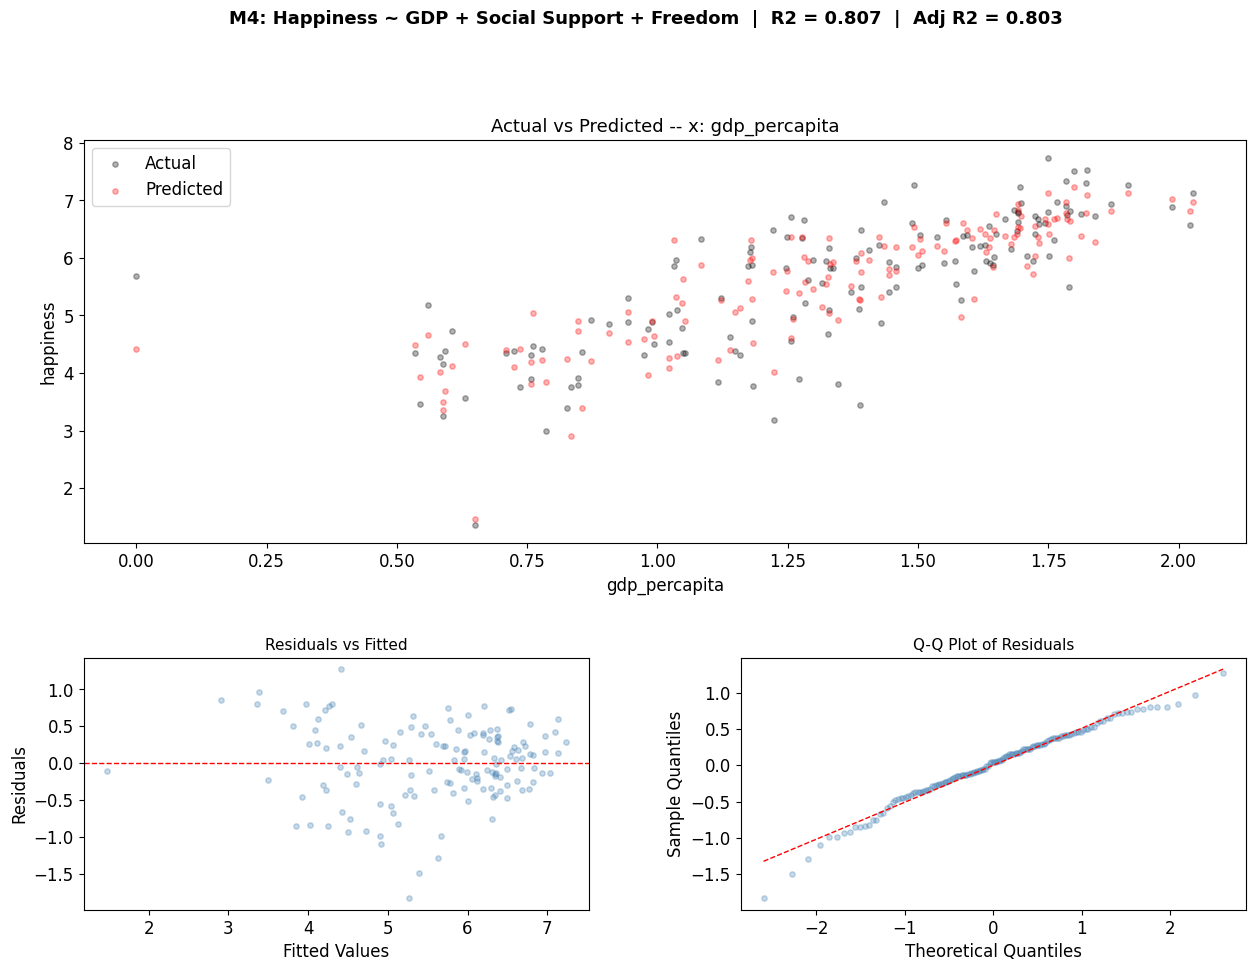

In [17]:
# Add social support (having someone to count on) -- one of the strongest WHR predictors
model4 = fit_and_plot(
    formula='happiness ~ gdp_percapita + social_support + freedom_life_choices',
    data=world_happiness,
    model_name='M4: Happiness ~ GDP + Social Support + Freedom',
    x_var='gdp_percapita'
)

### Model 5 — GDP + Life Expectancy + Social Support + Freedom

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     169.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.46e-52
Time:                        20:29:36   Log-Likelihood:                -99.463
No. Observations:                 145   AIC:                             208.9
Df Residuals:                     140   BIC:                             223.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

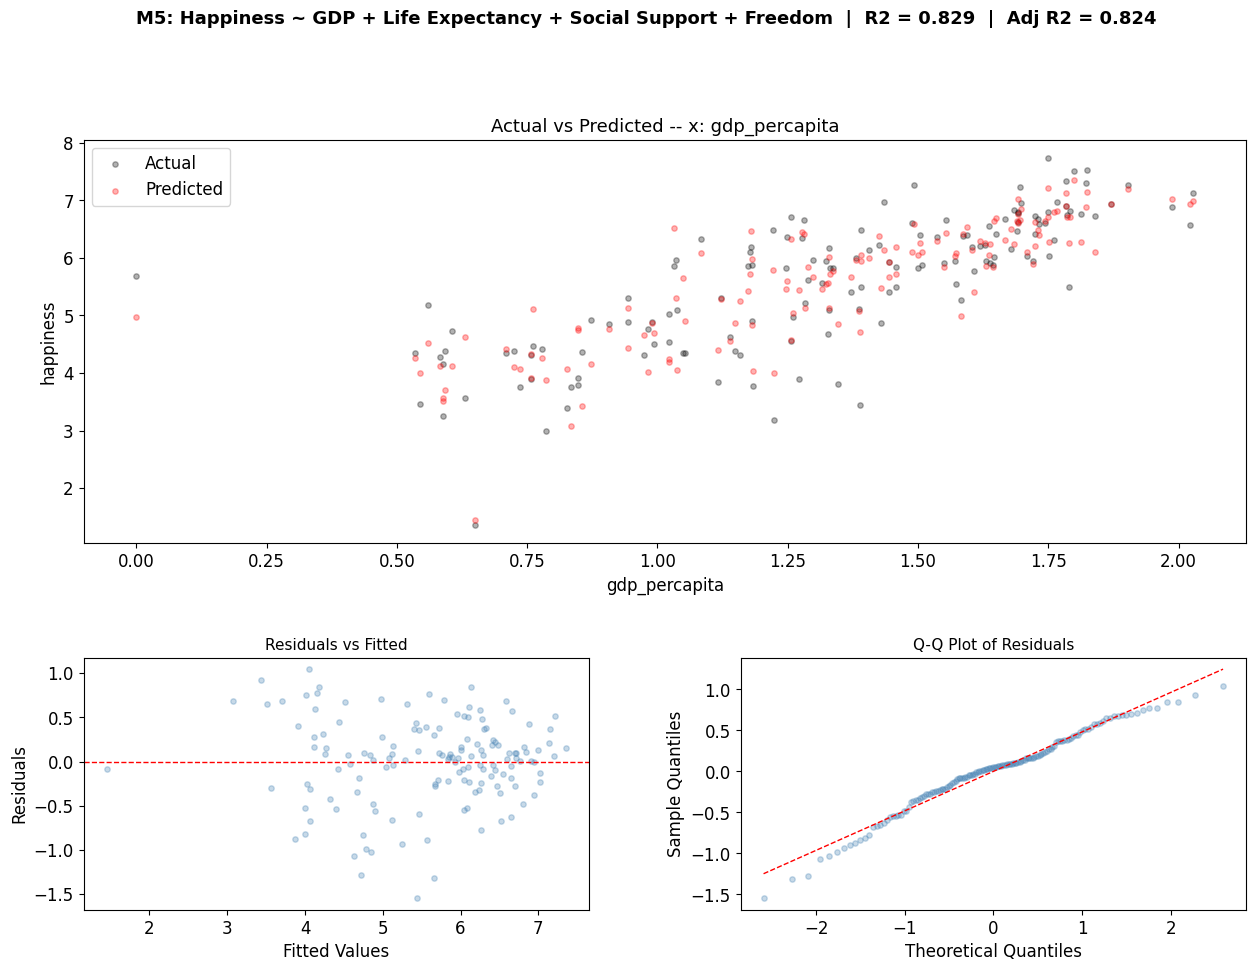

In [18]:
# Full model: add healthy life expectancy as the fourth predictor
model5 = fit_and_plot(
    formula='happiness ~ gdp_percapita + healthy_life_expectancy + social_support + freedom_life_choices',
    data=world_happiness,
    model_name='M5: Happiness ~ GDP + Life Expectancy + Social Support + Freedom',
    x_var='gdp_percapita'
)

## 7. Model Comparison

`summary_col` lines up all models side by side 

**What to look for:** rising Adj. R-squared, falling Residual SE, and coefficients that remain stable across models (robust predictors).

In [19]:
# Side-by-side coefficient table with significance stars
summary = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,                  # * p<0.05, ** p<0.01, *** p<0.001
    float_format='%0.3f',        # 3 decimal places
    model_names=['M1', 'M2', 'M3', 'M4', 'M5'],
    info_dict={
        'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"  # sqrt(MSE) = typical prediction error
    }
)
print(summary)


                           M1       M2       M3       M4       M5   
--------------------------------------------------------------------
Intercept               5.578*** 2.471*** 1.227*** 0.829*** 0.919***
                        (0.096)  (0.324)  (0.242)  (0.209)  (0.199) 
freedom_life_choices             4.149*** 2.622*** 2.043*** 1.938***
                                 (0.421)  (0.312)  (0.271)  (0.258) 
gdp_percapita                             1.807*** 0.987*** 0.532***
                                          (0.141)  (0.157)  (0.184) 
social_support                                     1.438*** 1.396***
                                                   (0.182)  (0.175) 
healthy_life_expectancy                                     1.179***
                                                            (0.285) 
R-squared               0.000    0.402    0.723    0.807    0.829   
R-squared Adj.          0.000    0.398    0.719    0.803    0.824   
Residual SE             1.158    

In [20]:
# Compact summary DataFrame: one row per metric, one column per model
models = {'M1': model1, 'M2': model2, 'M3': model3, 'M4': model4, 'M5': model5}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),               # number of countries
        'R2':          round(m.rsquared, 4),      # variance explained
        'Adj. R2':     round(m.rsquared_adj, 4),  # R2 penalised for extra predictors
        'Residual SE': round(m.scale ** 0.5, 3),  # typical prediction error
        'AIC':         round(m.aic, 1),            # lower = better fit/complexity trade-off
    }
    for name, m in models.items()
})

display(comparison)

,M1,M2,M3,M4,M5
N,147.000,146.0000,146.0000,146.0000,145.0000
R2,0.000,0.4025,0.7227,0.8072,0.8285
Adj. R2,0.000,0.3983,0.7189,0.8032,0.8236
Residual SE,1.158,0.9010,0.6160,0.5160,0.4890
AIC,461.400,386.0000,275.9000,224.9000,208.9000
